In [28]:
import pandas as pd

df = pd.read_csv('../data/master_data_12k_fixed.csv', usecols=["global_id", "team", "sequence"])

# make fasta file like
# >seq_id|team
# SEQUENCE

df["team"] = df["team"].apply(lambda x: x.replace(" ", "_"))
with open('../data/12k_binders_teams.fa', 'w') as f:
    for _, row in df.iterrows():
        f.write(f">{row['global_id']}|{row['team']}\n{row['sequence']}\n")

In [29]:
import numpy as np
import pandas as pd

# Convert sequences to a NumPy array of shape (N, L)
seqs = np.array([list(s) for s in df["sequence"]])
N, L = seqs.shape

# Encode as uint8 (faster for comparisons)
# seqs_encoded = np.frombuffer("".join(df["sequence"]), dtype=np.uint8).reshape(N, L)
seqs_encoded = np.array([list(s.encode("ascii")) for s in df["sequence"]], dtype=np.uint8)

# Compute pairwise identities
# This uses broadcasting and vectorization, no Python loops
ident_mat = (seqs_encoded[:, None, :] == seqs_encoded[None, :, :]).mean(axis=2)

# Zero out self-comparisons
np.fill_diagonal(ident_mat, 0.0)

# --- GLOBAL UNIQUENESS ---
max_ident_global = ident_mat.max(axis=1)

# --- CROSS-GROUP UNIQUENESS ---
groups = df["team"].to_numpy()
cross_mask = groups[:, None] != groups[None, :]

ident_cross = np.where(cross_mask, ident_mat, 0.0)
max_ident_cross = ident_cross.max(axis=1)

# --- OUTPUT ---
df["max_ident_global"] = max_ident_global
df["max_ident_cross"] = max_ident_cross

Global max: 0.9875
Global min: 0.1375
Global mean: 0.6943254728772601
Global median: 0.7375
Cross-group max: 0.65
Cross-group min: 0.1375
Cross-group mean: 0.2724939588367636
Cross-group median: 0.275


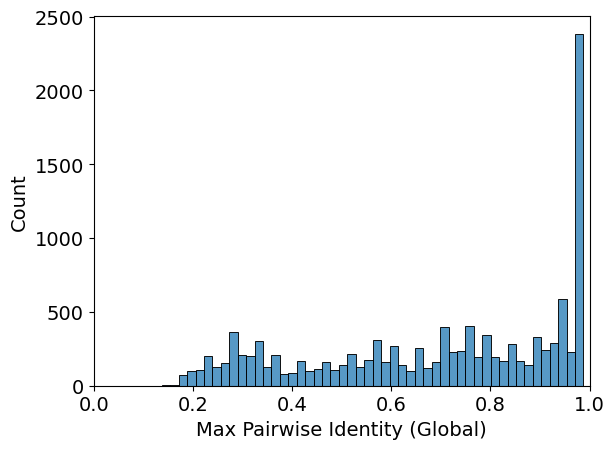

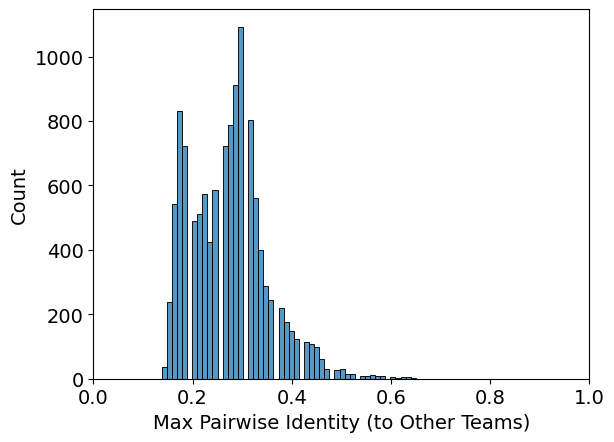

In [ ]:
# plot max ident as two separate plots, no sub plots, save separately
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure()
sns.histplot(df["max_ident_global"], bins=50)
plt.xlabel("Max Pairwise Identity (Global)", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlim(0,1)
plt.savefig('../results/pident/max_str_ident_global_histogram.png', dpi=300)


plt.figure()
sns.histplot(df["max_ident_cross"], bins=50)
plt.xlabel("Max Pairwise Identity (to Other Teams)", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlim(0,1)
plt.savefig('../results/pident/max_str_ident_cross_histogram.png', dpi=300)

# print min/max/mean/median from each
print(f"Global max: {df['max_ident_global'].max()}")
print(f"Global min: {df['max_ident_global'].min()}")
print(f"Global mean: {df['max_ident_global'].mean()}")
print(f"Global median: {df['max_ident_global'].median()}")

print(f"Cross-group max: {df['max_ident_cross'].max()}")
print(f"Cross-group min: {df['max_ident_cross'].min()}")
print(f"Cross-group mean: {df['max_ident_cross'].mean()}")
print(f"Cross-group median: {df['max_ident_cross'].median()}")

df.to_csv("../data/pident_str.csv", index=False)

In [34]:
import pandas as pd
import numpy as np

# -------------------------------------------------------------------
# 1. Load alignments
# -------------------------------------------------------------------
tsv_path = "../data/allbyall/all_vs_all.tsv"
cols = ["query", "target", "pident", "alnlen", "qlen", "tlen", "qcov", "tcov"]
df = pd.read_csv(tsv_path, sep="\t", header=None, names=cols)

for c in ["pident", "alnlen", "qlen", "tlen", "qcov", "tcov"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# ---------------------------------------------------------
# 2. Parse sequence id and group from headers
# ---------------------------------------------------------
all_labels = pd.Index(df["query"].unique()).union(df["target"].unique())

# turn into Series so we can use .str methods
label_series = pd.Series(all_labels, name="label")

# get first token before any whitespace
label_token = label_series.str.split(" ", n=1, expand=True)[0]

# split by '|' into id and group
parts = label_token.str.split("|", n=1, expand=True)
id_part = parts[0]
group_part = parts[1].fillna("NA")

label_map = pd.DataFrame({
    "label": all_labels,
    "id": id_part.values,
    "group": group_part.values
}).set_index("label")

# join back for query and target
df = df.join(
    label_map.rename(columns={"id": "query_id", "group": "query_group"}),
    on="query",
)
df = df.join(
    label_map.rename(columns={"id": "target_id", "group": "target_group"}),
    on="target",
)

# ---------------------------------------------------------
# 3. Filter and compute
# ---------------------------------------------------------
# df = df[(df["qcov"] >= 0.9) & (df["tcov"] >= 0.9)]
df = df[df["query_id"] != df["target_id"]]

max_global = df.groupby("query_id")["pident"].max().rename("max_pident_global")

cross = df[df["query_group"] != df["target_group"]]
max_other_group = (
    cross.groupby("query_id")["pident"].max().rename("max_pident_other_group")
)

seq_meta = (
    label_map.reset_index(drop=False)[["id", "group"]]
    .drop_duplicates("id")
    .set_index("id")
)

out = seq_meta.join(max_global).join(max_other_group)
out[["max_pident_global", "max_pident_other_group"]] = out[
    ["max_pident_global", "max_pident_other_group"]
].fillna(0.0)
out = out.reset_index().rename(columns={"index": "id", "group": "seq_group"})

out["id"] = out["id"].map(int)
out["max_pident_global"] = out["max_pident_global"].map(lambda x: float(x)/100)
out["max_pident_other_group"] = out["max_pident_other_group"].map(lambda x: float(x)/100)
out.sort_values(by="id")

,id,seq_group,max_pident_global,max_pident_other_group
3112,1,Antigeniuses,0.958,0.624
4223,2,Antigeniuses,0.960,0.624
5334,3,Antigeniuses,0.971,0.631
6445,4,Antigeniuses,0.960,0.617
7556,5,Antigeniuses,0.872,0.624
...,...,...,...,...
2216,11997,Leah_labs,0.814,0.000
2217,11998,Leah_labs,0.518,0.000
2218,11999,Leah_labs,0.682,0.000
2222,12000,Leah_labs,0.805,0.000


Global max: 1.0
Global min: 0.0
Global mean: 0.6212563119740022
Global median: 0.698
Cross-group max: 1.0
Cross-group min: 0.0
Cross-group mean: 0.0742654778768436
Cross-group median: 0.0


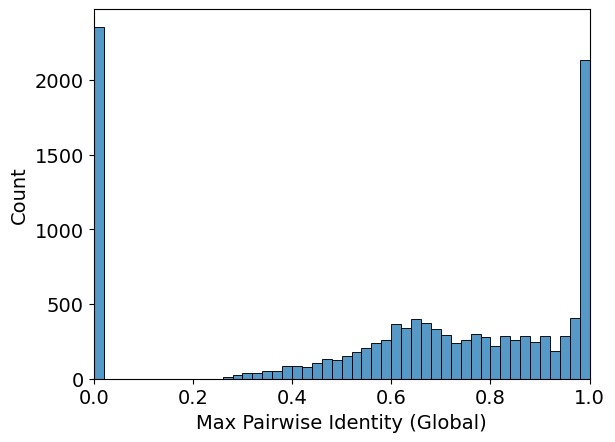

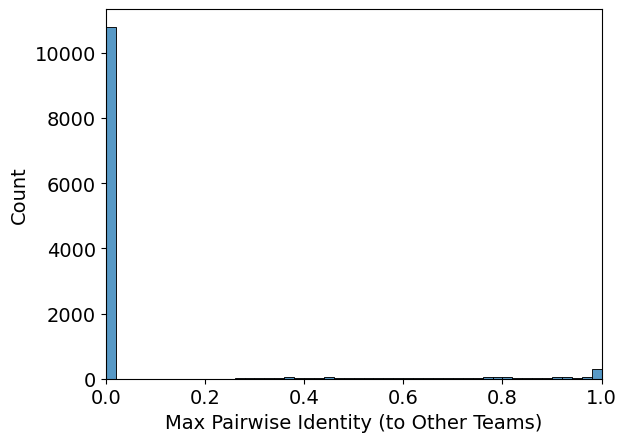

In [35]:
# plot histograms
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure()
sns.histplot(out["max_pident_global"], bins=50)
plt.xlabel("Max Pairwise Identity (Global)", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlim(0,1)
plt.savefig('../results/pident/max_seq_ident_global_histogram.png', dpi=300)
plt.figure()
sns.histplot(out["max_pident_other_group"], bins=50)
plt.xlabel("Max Pairwise Identity (to Other Teams)", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlim(0,1)
plt.savefig('../results/pident/max_seq_ident_other_group_histogram.png', dpi=300)

print(f"Global max: {out['max_pident_global'].max()}")
print(f"Global min: {out['max_pident_global'].min()}")
print(f"Global mean: {out['max_pident_global'].mean()}")
print(f"Global median: {out['max_pident_global'].median()}")
print(f"Cross-group max: {out['max_pident_other_group'].max()}")
print(f"Cross-group min: {out['max_pident_other_group'].min()}")
print(f"Cross-group mean: {out['max_pident_other_group'].mean()}")
print(f"Cross-group median: {out['max_pident_other_group'].median()}")